# 1D Velocity integration

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [ ]:
def mexican_hat_1d(x, A_exc, sigma_exc, A_inh, sigma_inh):
    return A_exc*np.e**(-x**2/sigma_exc**2) - A_inh*np.e**(-x**2/sigma_inh**2)

In [ ]:
A_exc = 0.3
sigma_exc = 5.0
A_inh = 0.2
sigma_inh = 10.0
M = 100
xVals = np.linspace(-M/2, M/2, M)


w = mexican_hat_1d(xVals, A_exc, sigma_exc, A_inh, sigma_inh)

In [ ]:
def r(s):
    return np.where(s>0, s, 0)

def I_rec(wR, rR, wL, rL):
    return scipy.ndimage.convolve1d(rL, wL, mode='wrap') + scipy.ndimage.convolve1d(rR, wR, mode='wrap')

def ds(sR, sL, t):
    rL = r(sL)
    rR = r(sR)
    I_vals = I_rec(wR, rR, wL, rL)
    return 1/tau * (-sR + I_vals + BR(t)), 1/tau * (-sL + I_vals + BL(t))

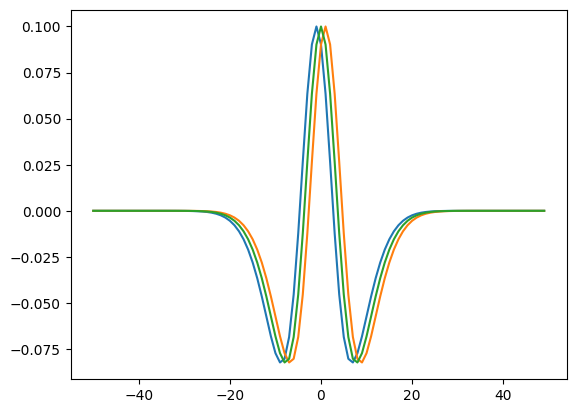

In [ ]:
B0 = 1.5
alpha = 0.5
l = 1

def v(t):
    if 300e-3 < t and t < 700e-3:
        return 1
    else:
        return 0

BR = lambda t: B0*(1+alpha*v(t))
BL = lambda t: B0*(1-alpha*v(t))



wL = np.zeros(M)
wL[:-l] = w[l:]
wL[-l:] = w[:l]

wR = np.zeros(M)
wR[:l] = w[-l:]
wR[l:] = w[:-l]

plt.plot(xVals, wL)
plt.plot(xVals, wR)
plt.plot(xVals, w)

1.1. Write a simulation class or function for this 2-population integrator. Use the previous parameters,
but set B0 = 1.5, α= 0.5, and weight shift l = 1.0. Run the simulation for 1000 ms with a timestep of
1 ms. For the first 300 ms, set v = 0 to let the activity pattern stabilize, and you should observe stable
bumps. From t= 300 ms to 700 ms, apply a constant velocity v = 1.0. For t>700 ms, v = 0. Plot the
sum of the firing rates rtotal(x,t) = rR(x,t) + rL(x,t) over time.

In [ ]:
def two_pop_solver(ds, s0L, s0R, tSpan, dt, tau, BL, BR, wL, wR, r):

    t = np.arange(tSpan[0], tSpan[1], dt)

    sL = np.zeros((len(t), len(s0L)))
    sR = np.zeros((len(t), len(s0R)))
    sL[0] = s0L
    sR[0] = s0R



    for i in range(1, len(t)):
        dsR, dsL = ds(sR[i-1], sL[i-1], t[i-1])
        sL[i] = sL[i-1] + dt * dsL
        sR[i] = sR[i-1] + dt * dsR

    return sL, sR, t

In [ ]:
tau = 10e-3
M = 100

s0L = np.random.uniform(0,0.1, M)
s0R = np.random.uniform(0,0.1, M)

sL, sR, t  = two_pop_solver(ds, s0L, s0R, [0,1000e-3], 1e-3, tau, BL, BR, wL, wR, r)

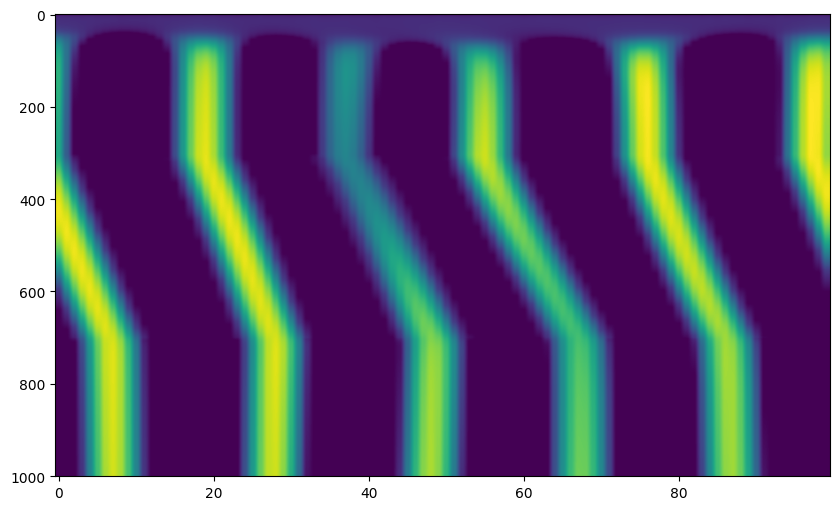

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
rTot = r(sL)+r(sR)
plt.imshow(rTot, aspect='auto')
plt.show()

In [ ]:
B0 = 1.5
alpha = 0.5
vels1 = np.linspace(-2, -0.5, 5)
vels2 = np.linspace(0.5, 2, 5)
vels = np.zeros(11)
vels[0]=0
vels[0:6]=vels1
vels[6:]=vels2

def v(t):
    return vels[int(t//(300e-3))]
     

BR = lambda t: B0*(1+alpha*v(t))
BL = lambda t: B0*(1-alpha*v(t))

1.625 2.0 2.0


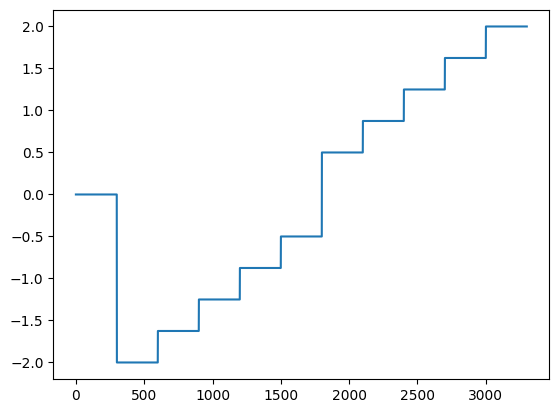

In [ ]:
tSpan = [0,11*300e-3]
dt = 1e-3
t = np.arange(tSpan[0], tSpan[1], dt)
vs = np.zeros(len(t))
for i in range(len(t)):
    vs[i] = v(t[i])

plt.plot(np.linspace(0, len(t), len(t)), vs)
print(vs[2999], vs[3000], vs[3299])

In [ ]:
tau = 10e-3
M = 100

s0L = np.random.uniform(0,0.1, M)
s0R = np.random.uniform(0,0.1, M)

sL, sR, t  = two_pop_solver(ds, s0L, s0R, [0,11*300e-3], 1e-3, tau, BL, BR, wL, wR, r)

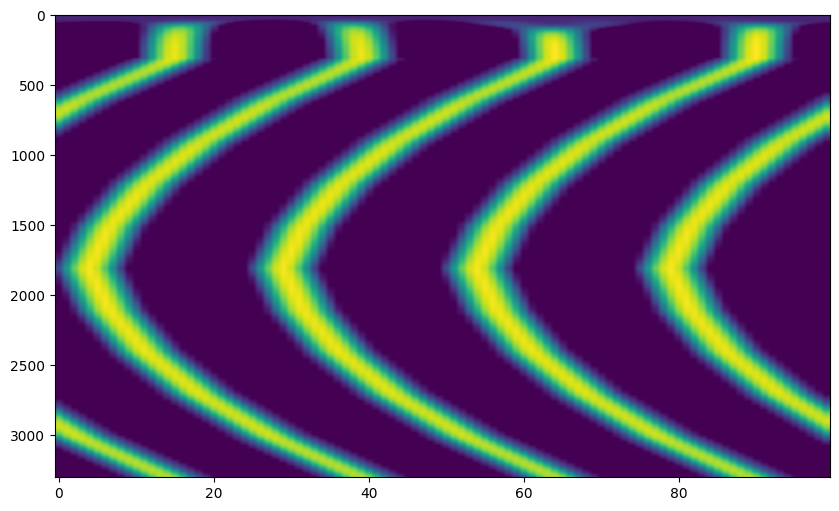

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
rTot = r(sL)+r(sR)
plt.imshow(rTot, aspect='auto')
plt.show()

In [ ]:
print(rTot)
print(len(rTot))
print(rTot[0, -5:])

[[0.10646523 0.10725266 0.06697117 ... 0.06190972 0.12870678 0.1346807 ]
 [0.38064554 0.38129681 0.34457616 ... 0.3382968  0.39941821 0.40561812]
 [0.57880302 0.57935005 0.54585792 ... 0.53848679 0.59446666 0.60085365]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]
3300
[0.1518756  0.03451655 0.06190972 0.12870678 0.1346807 ]


In [ ]:
time_intervals = np.linspace(0, 3300, 11)
d_index = np.zeros((11, 300))

for i in range(11):
    k0 = np.where(rTot[i*300] == max(rTot[i*300]))[0]
    for j in range(300):
        if k < 10:
            kLeft = np.where(rTot[i*300+j, 0:k0+10] == max(rTot[i*300+j, 0:k0+10]))[0]
            kRight = np.where(rTot[i*300+j, (k0-10):] == max(rTot[i*300+j, k0-10:]))[0]

            if rTot[i*300+j, kLeft] > rTot[i*300+j, kRight]:
                k1 = kLeft
            else:
                k1 = kRight
            
        if k > 89:

            kLeft = np.where(rTot[i*300+j, 0:k0-90] == max(rTot[i*300+j, 0:k0-90]))[0]
            kRight = np.where(rTot[i*300+j, (k0-10):] == max(rTot[i*300+j, k0-10:]))[0]

            if rTot[i*300+j, kLeft] > rTot[i*300+j, kRight]:
                k1 = kLeft
                d_index[i, ]
            else:
                k1 = kRight

        else:
            k1 = np.where(rTot[i*300+j, k0-10:k0+10] == max(rTot[i*300+j, k0-10:k0+10]))[0]
        



    print(init)

[81]
[4]
[47]
[13]
[83]
[56]
[52]
[55]
[82]
[12]
[45]


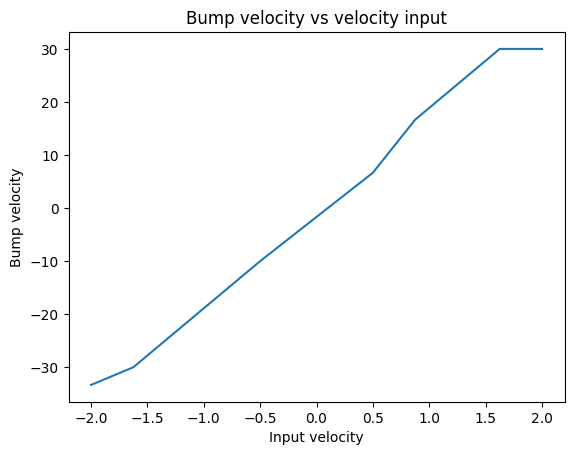

In [ ]:

d_ind = np.zeros(11)
for i in range(11):
    k0 = np.argmax(rTot[i*300, 20:80]) + 20
    k1 = np.argmax(rTot[i*300+299, k0-10:k0+10]) + k0 - 10
    d_ind[i] = k1 - k0

# What should the units be here? Do we divide by 300e-3? or by 300?
v_bump = d_ind/300e-3
plt.plot(vels[1:], v_bump[1:])
plt.title("Bump velocity vs velocity input")
plt.xlabel("Input velocity")
plt.ylabel("Bump velocity")
plt.show()